# Inter-Element Distance Sweep

This notebook examines how the spacing between diffractive elements in the cascade affects focusing performance. It loads results from the `inter_elem_dist_sweeps` study and plots efficiency and focal spot width as a function of the inter-element distance for different numbers of elements. This helps identify optimal element spacings and shows the design's sensitivity to this geometric parameter.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [2]:
import sys
from pathlib import Path

repo_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(repo_root))

from src.util import colors_list


In [3]:
matplotlib.rcParams['figure.dpi'] = 200
matplotlib.rcParams.update({'font.size': 24})

In [4]:
fzp_color = (np.float64(0.4), np.float64(0.6509803921568628), np.float64(0.11764705882352941), np.float64(1.0))

In [5]:
path = repo_root / "paper_data"

results = []
N_runs = 1
for i in range(N_runs):
    res = np.load(path / f"inter_elem_dist_sweeps_results_run_{i}.npz", allow_pickle=True)
    results.append(res)
params = np.load(path / "inter_elem_dist_sweeps_params.npy", allow_pickle=True).item()
sweep_arrs = np.load(path / "inter_elem_dist_sweeps_sweep_arrays.npy", allow_pickle=True).item()

In [6]:
ieds = sweep_arrs["inter_elem_dists"]
Nelems = sweep_arrs["Nelems"]

In [7]:
opt_intensities = np.zeros((N_runs, len(Nelems), len(ieds), params["Nx"]))
fzp_intensities = np.zeros((N_runs, len(Nelems), len(ieds), params["Nx"]))
opt_efficiencies = np.zeros((N_runs, len(Nelems), len(ieds)))
fzp_efficiencies = np.zeros((N_runs, len(Nelems), len(ieds)))
opt_widths = np.zeros((N_runs, len(Nelems), len(ieds)))
fzp_widths = np.zeros((N_runs, len(Nelems), len(ieds)))

for i in range(N_runs):
    opt_intensities_i = results[i]["opt_intensities"]
    opt_efficiencies_i = results[i]["opt_efficiencies"]
    fzp_efficiencies_i = results[i]["fzp_efficiencies"]
    opt_widths_i = results[i]["opt_widths"]
    fzp_intensities_i = results[i]["fzp_intensities"]
    opt_widths_i = results[i]["opt_widths"]
    fzp_widths_i = results[i]["fzp_widths"]
   
    opt_efficiencies[i] = opt_efficiencies_i
    fzp_efficiencies[i] = fzp_efficiencies_i
    opt_intensities[i] = opt_intensities_i
    opt_widths[i] = opt_widths_i
    fzp_intensities[i] = fzp_intensities_i
    fzp_widths[i] = fzp_widths_i

In [8]:
opt_efficiencies_mean = np.mean(opt_efficiencies, axis=0)
opt_efficiencies_std = np.std(opt_efficiencies, axis=0)

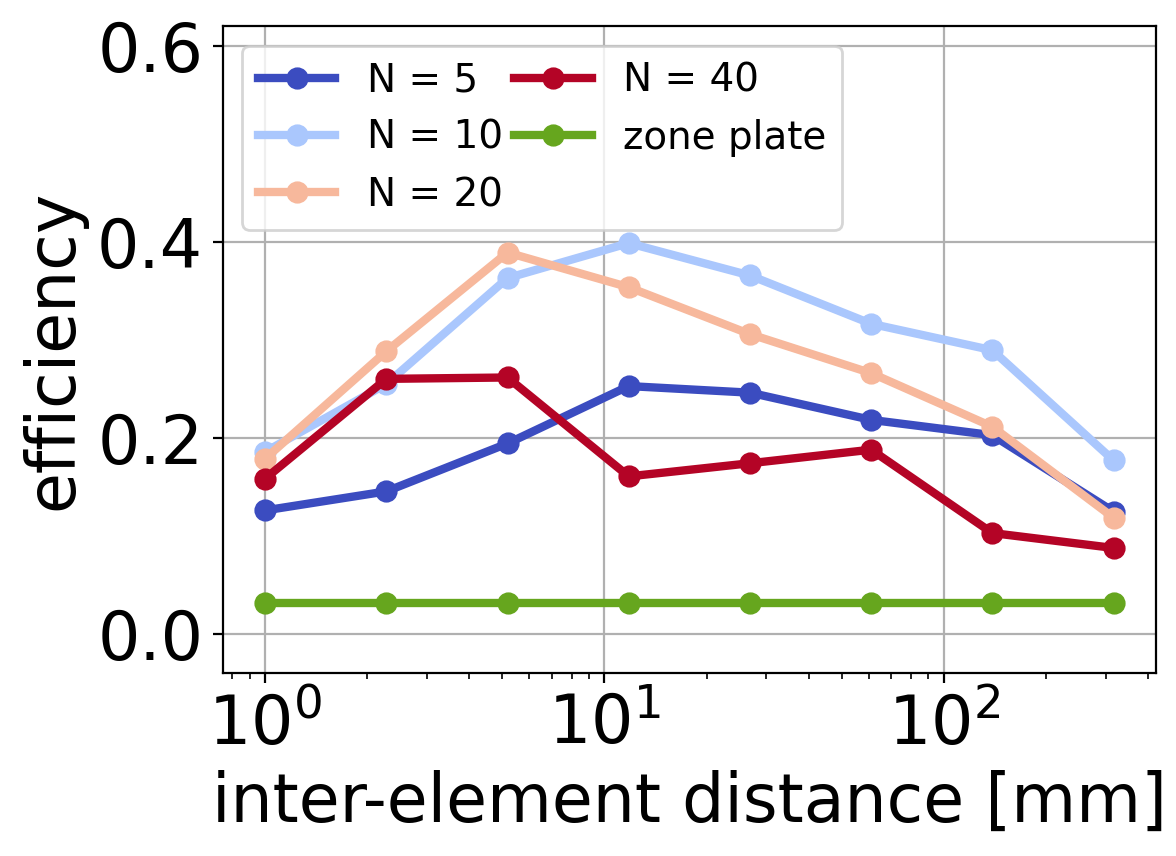

In [9]:
colors = colors_list(len(Nelems))
for i in range(len(Nelems)):
    plt.plot(
        ieds*1e3, 
        opt_efficiencies_mean[i], 
        linewidth=3, 
        marker='o', 
        markersize=7, 
        color=colors[i], 
        label = f"N = {Nelems[i]}"
    )

plt.plot(
        ieds*1e3, 
        fzp_efficiencies[0][i], 
        linewidth=3, 
        marker='o', 
        markersize=7, 
        color=fzp_color, 
        label = "zone plate"
    )

plt.xlabel("inter-element distance [mm]")
plt.ylabel("efficiency")
plt.semilogx()
plt.tight_layout()
# plt.xlim(10, 20)
plt.ylim(-0.04, .62)
plt.legend(fontsize=14, ncols=2, columnspacing=0.3, loc='upper left')
plt.grid(True)
plt.tight_layout()
# plt.savefig(f"inter_elem_distance{ID}.png")
plt.show()